In [1]:
import geopandas as gpd
import xarray as xr

RUTA_SHAPEFILE_MEXICO = "../data/001_raw/INEGI/00ent.shp"
RUTA_MASCARA_MEXICO = "../data/002_processed/mexico_mask.gpkg"

CRS original: PROJCS["MEXICO_ITRF_2008_LCC",GEOGCS["ITRF2008",DATUM["International_Terrestrial_Reference_Frame_2008",SPHEROID["GRS 1980",6378137,298.257222101,AUTHORITY["EPSG","7019"]],AUTHORITY["EPSG","1061"]],PRIMEM["Greenwich",0],UNIT["Degree",0.0174532925199433]],PROJECTION["Lambert_Conformal_Conic_2SP"],PARAMETER["latitude_of_origin",12],PARAMETER["central_meridian",-102],PARAMETER["standard_parallel_1",17.5],PARAMETER["standard_parallel_2",29.5],PARAMETER["false_easting",2500000],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH]]
Filas antes de dissolve: 32


<Axes: >

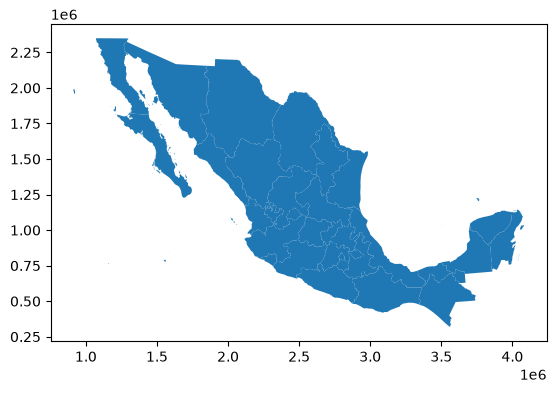

In [2]:
mexico_shp = gpd.read_file(RUTA_SHAPEFILE_MEXICO)

print("CRS original:", mexico_shp.crs)
print("Filas antes de dissolve:", len(mexico_shp)) 

mexico_shp.plot()

Filas después de dissolve: 1
CRS: EPSG:4326


<Axes: >

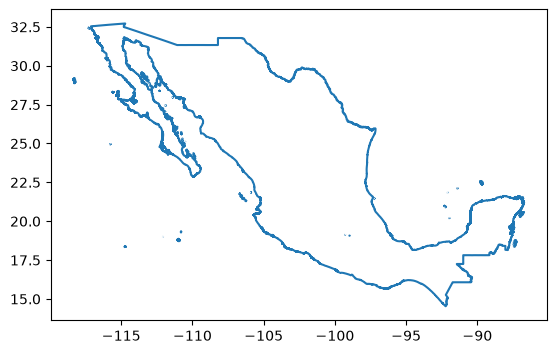

In [3]:
mexico_disuelto = mexico_shp.to_crs("EPSG:4326").dissolve()

print("Filas después de dissolve:", len(mexico_disuelto))
print("CRS:", mexico_disuelto.crs)

mexico_disuelto.boundary.plot()

In [4]:
mexico_disuelto.to_file(RUTA_MASCARA_MEXICO, driver="GPKG")

print("Guardado en:", RUTA_MASCARA_MEXICO)

Guardado en: ../data/002_processed/mexico_mask.gpkg


In [5]:
import os

peso_kb = os.path.getsize(RUTA_MASCARA_MEXICO) / 1024
print(f"Tamaño del archivo: {peso_kb:.1f} KB")

Tamaño del archivo: 8560.0 KB


CRS: EPSG:4326
Filas: 1


<Axes: >

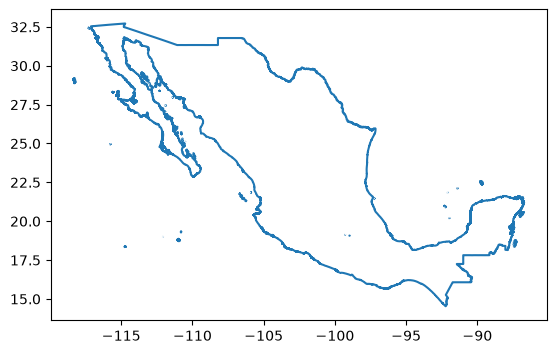

In [6]:
mexico_desde_gpkg = gpd.read_file(RUTA_MASCARA_MEXICO)

print("CRS:", mexico_desde_gpkg.crs)
print("Filas:", len(mexico_desde_gpkg))  
mexico_desde_gpkg.boundary.plot()

In [7]:
son_iguales = mexico_disuelto.geometry.iloc[0].equals(mexico_desde_gpkg.geometry.iloc[0])
print("¿La geometría releída es idéntica a la original?", son_iguales)
assert son_iguales, "el .gpkg no guardó la geometría correctamente"

¿La geometría releída es idéntica a la original? True


In [8]:
import sys
sys.path.insert(0, "..")
from scripts.mask_convert import mask_netcdf

RUTA_NETCDF_PRUEBA = "../data/001_raw/ECMWF_utci_2022_mexico_anual.nc"

resultado_shp = mask_netcdf(
    netcdf_path=RUTA_NETCDF_PRUEBA,
    shapefile_path=RUTA_SHAPEFILE_MEXICO,
)

resultado_gpkg = mask_netcdf(
    netcdf_path=RUTA_NETCDF_PRUEBA,
    shapefile_path=RUTA_MASCARA_MEXICO,
)

iguales = resultado_shp["utci"].equals(resultado_gpkg["utci"])
print("¿mask_netcdf da el mismo resultado con .shp que con .gpkg?", iguales)
assert iguales, "el resultado cambió al usar el .gpkg en vez del .shp"

¿mask_netcdf da el mismo resultado con .shp que con .gpkg? True


In [9]:
resultado_gpkg_rapido = mask_netcdf(
    netcdf_path=RUTA_NETCDF_PRUEBA,
    shapefile_path=RUTA_MASCARA_MEXICO,
)

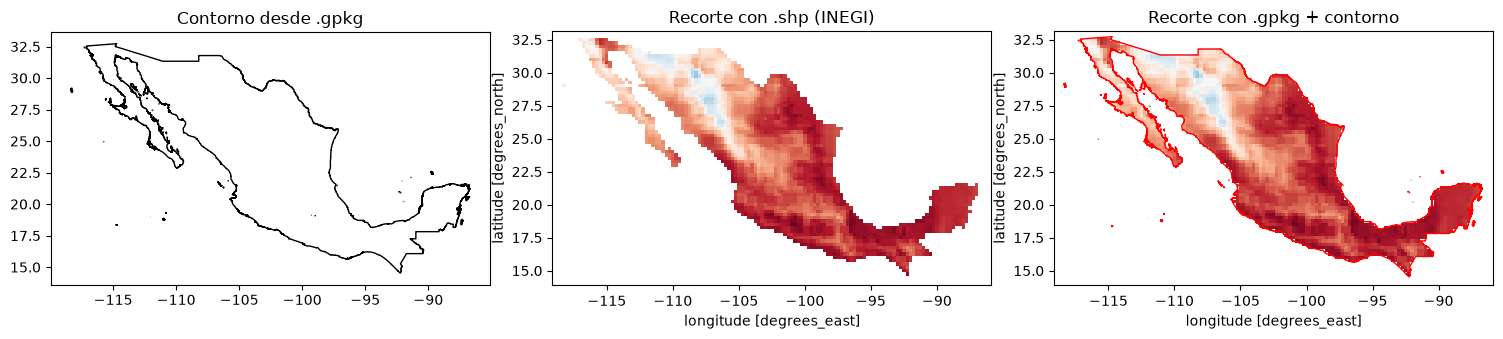

In [10]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

mexico_desde_gpkg.boundary.plot(ax=axes[0], color="black", linewidth=1)
axes[0].set_title("Contorno desde .gpkg")
axes[0].set_aspect("equal")

resultado_shp["utci"].isel(time=0).plot(ax=axes[1], add_colorbar=False)
axes[1].set_title("Recorte con .shp (INEGI)")
axes[1].set_aspect("equal")

resultado_gpkg["utci"].isel(time=0).plot(ax=axes[2], add_colorbar=False)
mexico_desde_gpkg.boundary.plot(ax=axes[2], color="red", linewidth=1)
axes[2].set_title("Recorte con .gpkg + contorno")
axes[2].set_aspect("equal")

plt.tight_layout()

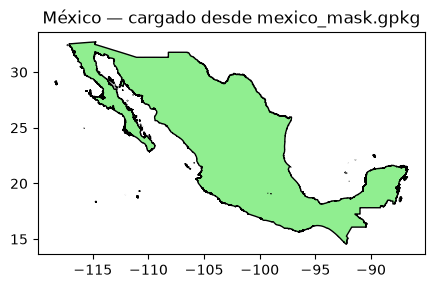

In [11]:
fig, ax = plt.subplots(figsize=(5, 5))

mexico_desde_gpkg.plot(ax=ax, color="lightgreen", edgecolor="black", linewidth=1)

ax.set_title("México — cargado desde mexico_mask.gpkg")
ax.set_aspect("equal")